## 1.1 Rotation Matrix

A rotation matrix is used to represent the rotation of a vector in a coordinate system while preserving its magnitude. For example, a rotation about the x-axis by an angle $\theta$ is given by

$$
R_x(\theta) =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\theta & -\sin\theta \\
0 & \sin\theta & \cos\theta
\end{bmatrix}
$$

which shows that the x-component remains unchanged, while the y and z components are rotated in the yz-plane.



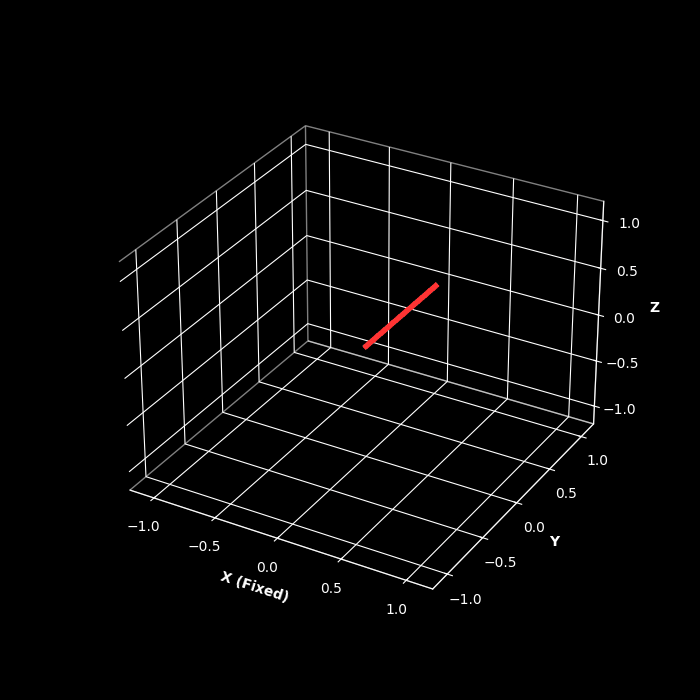

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import base64
import os

# 1. Set Dark Mode Styles
plt.style.use('dark_background')

fig = plt.figure(figsize=(7, 7), facecolor='black')
ax = fig.add_subplot(111, projection='3d')

# Set pane colors to black and grid to white
ax.set_facecolor('black')
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Force grid and ticks to be visible/white
ax.grid(True, color='white', linestyle='--', linewidth=0.5)
ax.tick_params(colors='white')

# Animation elements
vector_line, = ax.plot([], [], [], color='#FF3333', lw=4) # Neon Red
trace_line, = ax.plot([], [], [], color='#33FF33', lw=1.5, alpha=0.7) # Neon Green

trace_x, trace_y, trace_z = [], [], []

def init():
    ax.set_xlim3d(-1.2, 1.2)
    ax.set_ylim3d(-1.2, 1.2)
    ax.set_zlim3d(-1.2, 1.2)
    
    # White labels for Dark Theme
    ax.set_xlabel('X (Fixed)', color='white', fontweight='bold')
    ax.set_ylabel('Y', color='white', fontweight='bold')
    ax.set_zlabel('Z', color='white', fontweight='bold')
    
    trace_x.clear(); trace_y.clear(); trace_z.clear()
    return vector_line, trace_line

def update(frame):
    theta = np.radians(frame * 3.6) 
    v = np.array([0, 1, 0]) 
    
    # Rotation Matrix Rx(theta)
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])
    
    v_new = Rx @ v
    
    vector_line.set_data([0, v_new[0]], [0, v_new[1]])
    vector_line.set_3d_properties([0, v_new[2]])
    
    trace_x.append(v_new[0]); trace_y.append(v_new[1]); trace_z.append(v_new[2])
    trace_line.set_data(trace_x, trace_y)
    trace_line.set_3d_properties(trace_z)
    
    return vector_line, trace_line

# 2. Create Animation
ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.close()

# 3. Save and Encode
temp_file = "dark_rotation.gif"
ani.save(temp_file, writer=PillowWriter(fps=20))

with open(temp_file, "rb") as f:
    encoded = base64.b64encode(f.read()).decode('utf-8')

os.remove(temp_file)

# 4. Display with CSS for Dark Theme
display(HTML(f'''
<div style="text-align:center; background-color:black; padding:20px; border-radius:15px; border: 1px solid #444;">
    <img src="data:image/gif;base64,{encoded}" style="width:80%;">
    <p style="font-family:sans-serif; color:white; margin-top:10px;">
        <span style="color:#FF3333;">■</span> Vector Rotation $R_x(\\theta)$ 
        <span style="color:#33FF33; margin-left:15px;">■</span> YZ Plane Trace
    </p>
</div>
'''))


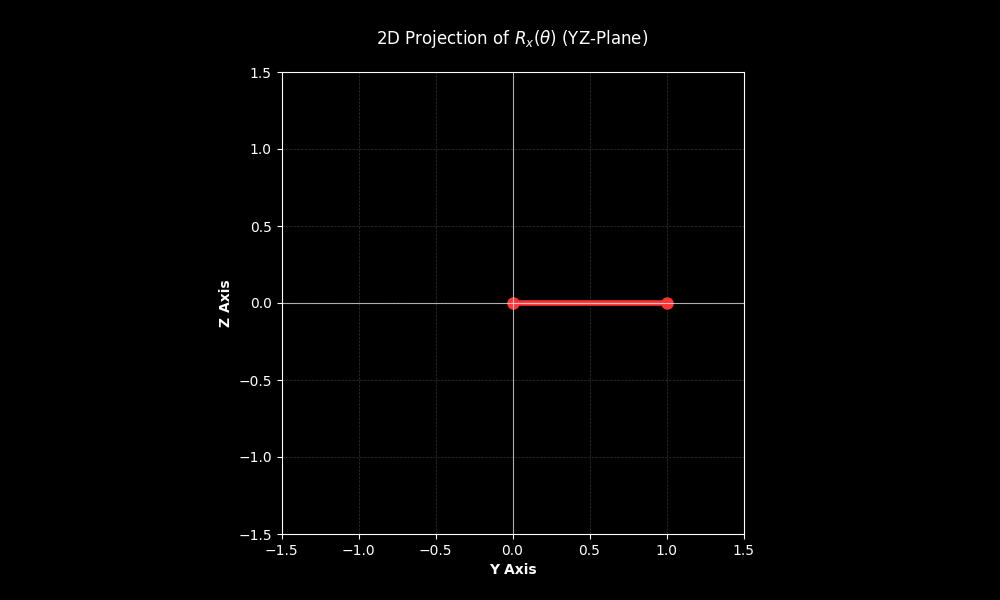

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import base64
import os

# 1. Set Dark Mode Styles
plt.style.use('dark_background')

# Create a wide 2D figure
fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
ax.set_facecolor('black')

# Neon elements
vector_line, = ax.plot([], [], color='#FF3333', lw=4, marker='o', markersize=8) # Red Vector
trace_line, = ax.plot([], [], color='#33FF33', lw=1.5, alpha=0.6, linestyle='--') # Green Trace

trace_y, trace_z = [], []

def init():
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    
    # Grid and Axis Styling
    ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.3)
    ax.axvline(0, color='white', linewidth=0.8, alpha=0.3)
    
    ax.set_xlabel('Y Axis', color='white', fontweight='bold')
    ax.set_ylabel('Z Axis', color='white', fontweight='bold')
    ax.set_title(r'2D Projection of $R_x(\theta)$ (YZ-Plane)', color='white', pad=20)
    
    trace_y.clear(); trace_z.clear()
    return vector_line, trace_line

def update(frame):
    # theta completes a full circle over 100 frames
    theta = np.radians(frame * 3.6) 
    
    # Starting vector on Y-axis [y=1, z=0]
    # Applying the 2D part of Rx(theta):
    # y' = cos(theta)*y - sin(theta)*z
    # z' = sin(theta)*y + cos(theta)*z
    y_new = np.cos(theta)
    z_new = np.sin(theta)
    
    # Update Vector
    vector_line.set_data([0, y_new], [0, z_new])
    
    # Update Trace
    trace_y.append(y_new)
    trace_z.append(z_new)
    trace_line.set_data(trace_y, trace_z)
    
    return vector_line, trace_line

# 2. Create Animation
ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.close()

# 3. Save as GIF to avoid flickering/errors
temp_file = "yz_rotation.gif"
ani.save(temp_file, writer=PillowWriter(fps=20))

with open(temp_file, "rb") as f:
    encoded = base64.b64encode(f.read()).decode('utf-8')

os.remove(temp_file)

# 4. Display Full Width
display(HTML(f'''
<div style="text-align:center; background-color:black; padding:10px; width:100%;">
    <img src="data:image/gif;base64,{encoded}" style="width:100%; max-width:800px; border: 1px solid #333; border-radius:10px;">
    <p style="color:white; font-family:sans-serif; margin-top:15px;">
        <span style="color:#FF3333;">●</span> <b>Vector Position</b> 
        <span style="color:#33FF33; margin-left:20px;">--</span> <b>Rotation Path</b>
    </p>
</div>
'''))